# Churn Prediction Modelling: Telco Customer Churn

**Purpose:** Train, evaluate, and compare churn prediction models. Document every decision — from handling class imbalance to selecting the final model.

**Notebook Structure:**
1. Setup & Data Preparation
2. Baseline Model — Logistic Regression
3. Ensemble Model — Random Forest
4. Gradient Boosting — XGBoost
5. Model Comparison
6. Feature Importance — SHAP
7. Final Model Selection & Saving

---

## 1. Setup & Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import sys
import os

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

from src.utils import PROCESSED_DIR, MODELS_DIR
from src.models.train import prepare_data

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, '03_features.csv'))
X, y, feature_cols = prepare_data(df)

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')
print(f'Churn rate: {y.mean():.2%}')
print(f'\nClass distribution:')
print(y.value_counts())

Features : 27
Samples  : 7,043
Churn rate: 26.54%

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# Stratified split preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train set: {X_train.shape[0]} samples | Churn rate: {y_train.mean():.2%}')
print(f'Test set : {X_test.shape[0]} samples  | Churn rate: {y_test.mean():.2%}')

Train set: 5634 samples | Churn rate: 26.54%
Test set : 1409 samples  | Churn rate: 26.54%


In [4]:
# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**Class imbalance handling strategy:**
- ~26.5% churn rate — moderate imbalance
- We use `class_weight='balanced'` for sklearn models and `scale_pos_weight` for XGBoost
- This avoids the model just predicting 'no churn' for everything
- We report **F1 on the churn class** and **ROC-AUC** as primary metrics (not accuracy)

In [5]:
def evaluate(model, X_t, y_t, name, scaled=False):
    """Unified evaluation function — returns metrics dict and plots confusion matrix."""
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]

    metrics = {
        'Model': name,
        'ROC-AUC': round(roc_auc_score(y_t, y_prob), 4),
        'F1 (Churn)': round(f1_score(y_t, y_pred), 4),
        'Precision': round(precision_score(y_t, y_pred), 4),
        'Recall': round(recall_score(y_t, y_pred), 4),
    }
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:<20}: {v}')
    print()
    print(classification_report(y_t, y_pred, target_names=['Retained', 'Churned']))

    return metrics, y_prob

all_metrics = []
all_probs = {}

## 2. Baseline Model: Logistic Regression

Always start with a simple baseline. If a complex model can't beat logistic regression, something is wrong like really wrong.

In [6]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

metrics_lr, proba_lr = evaluate(lr, X_test_scaled, y_test, 'Logistic Regression')
all_metrics.append(metrics_lr)
all_probs['Logistic Regression'] = proba_lr


  Logistic Regression
  ROC-AUC             : 0.8497
  F1 (Churn)          : 0.621
  Precision           : 0.5076
  Recall              : 0.7995

              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [7]:
# Cross-validation score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, scaler.transform(X), y, cv=cv, scoring='roc_auc')
print(f'LR Cross-Val ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

LR Cross-Val ROC-AUC: 0.8497 ± 0.0114


## 3. Ensemble Model: Random Forest

In [8]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

metrics_rf, proba_rf = evaluate(rf, X_test, y_test, 'Random Forest')
all_metrics.append(metrics_rf)
all_probs['Random Forest'] = proba_rf


  Random Forest
  ROC-AUC             : 0.8422
  F1 (Churn)          : 0.6238
  Precision           : 0.5539
  Recall              : 0.7139

              precision    recall  f1-score   support

    Retained       0.88      0.79      0.84      1035
     Churned       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



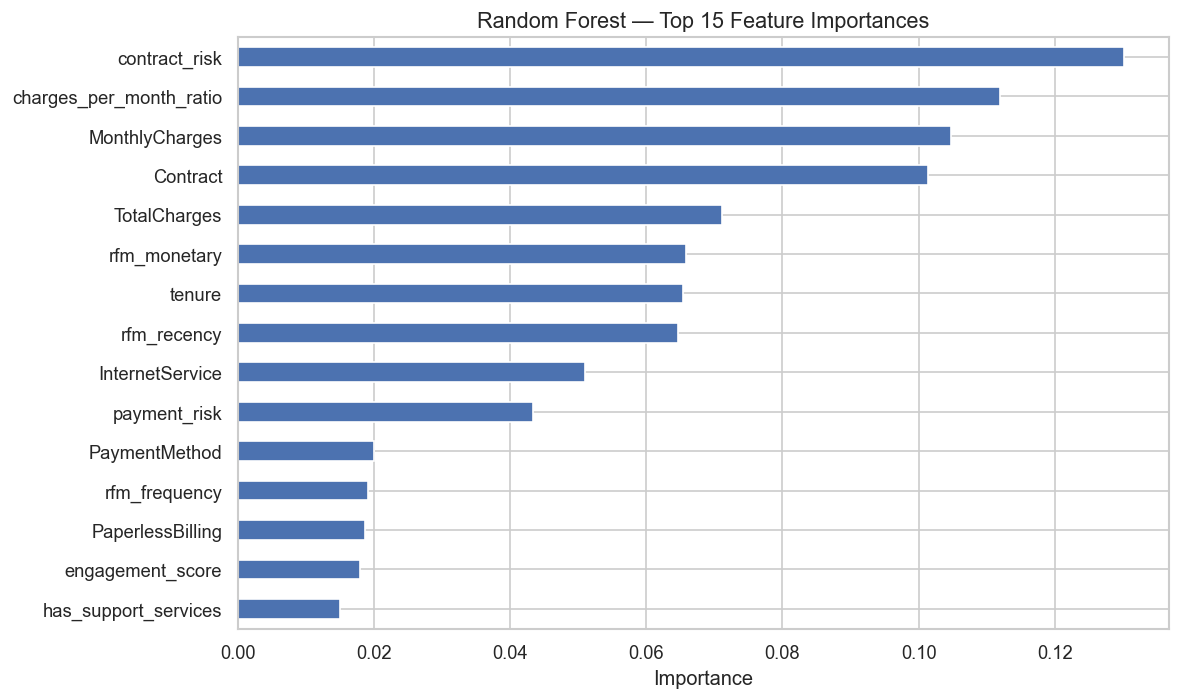

In [9]:
# RF feature importance (built-in)
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).sort_values().plot.barh(color='#4C72B0', ax=ax)
ax.set_title('Random Forest — Top 15 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 4. Gradient Boosting: XGBoost

In [10]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'Class ratio (neg/pos) = {scale_pos_weight:.2f}')

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb.fit(X_train, y_train)

metrics_xgb, proba_xgb = evaluate(xgb, X_test, y_test, 'XGBoost')
all_metrics.append(metrics_xgb)
all_probs['XGBoost'] = proba_xgb

Class ratio (neg/pos) = 2.77

  XGBoost
  ROC-AUC             : 0.8325
  F1 (Churn)          : 0.6268
  Precision           : 0.5419
  Recall              : 0.7433

              precision    recall  f1-score   support

    Retained       0.89      0.77      0.83      1035
     Churned       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



## 5. Model Comparison: ROC Curves

In [12]:
# Comparison table
comparison_df = pd.DataFrame(all_metrics).set_index('Model')
comparison_df.sort_values('ROC-AUC', ascending=False)

,ROC-AUC,F1 (Churn),Precision,Recall
Model,,,,
Logistic Regression,0.8497,0.6210,0.5076,0.7995
Random Forest,0.8422,0.6238,0.5539,0.7139
XGBoost,0.8325,0.6268,0.5419,0.7433


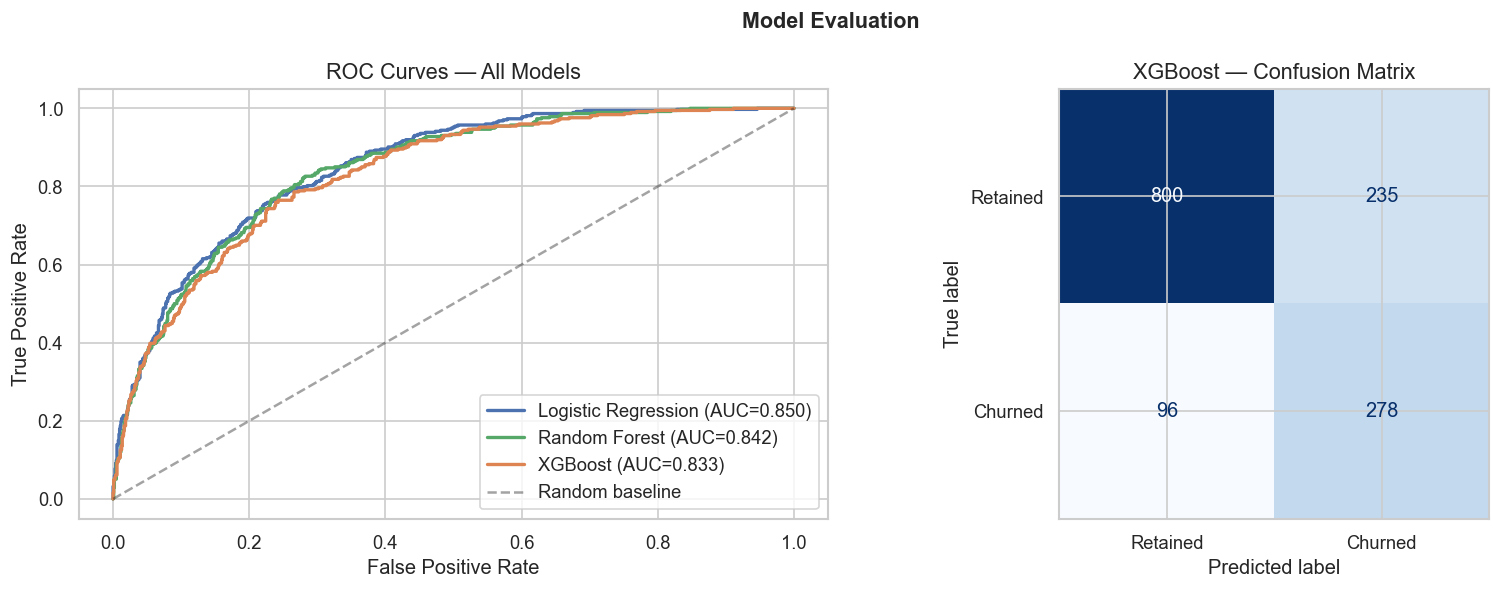

In [13]:
# ROC curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#4C72B0', 'Random Forest': '#55A868', 'XGBoost': '#DD8452'}

for name, proba in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=colors[name], lw=2)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend()

# Confusion matrix for best model (XGBoost)
cm = confusion_matrix(y_test, xgb.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost — Confusion Matrix')

plt.suptitle('Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Importance: SHAP

SHAP (SHapley Additive exPlanations) gives us **model-agnostic, interpretable** feature importance — essential for a marketing team that needs to understand *why* a customer is flagged as high risk.

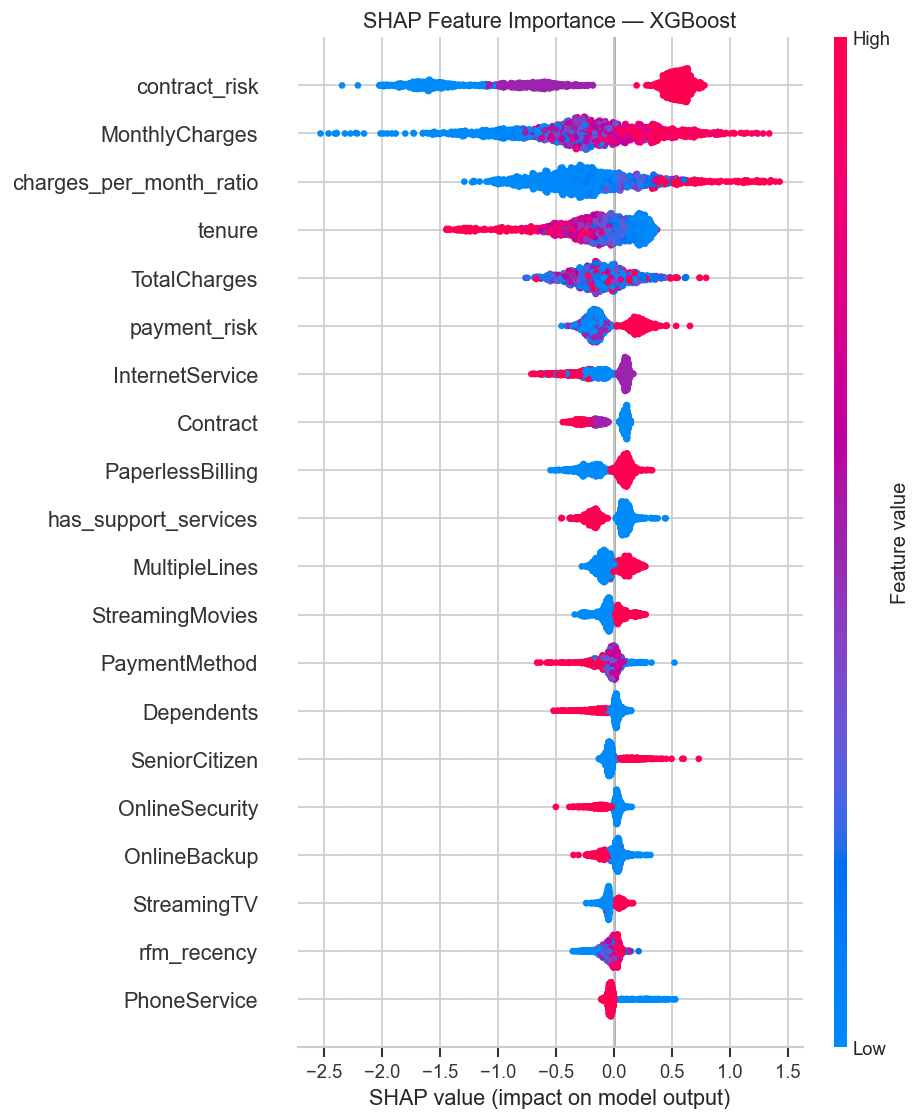

In [14]:
# SHAP values for XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows direction and magnitude of each feature's impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Feature Importance — XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

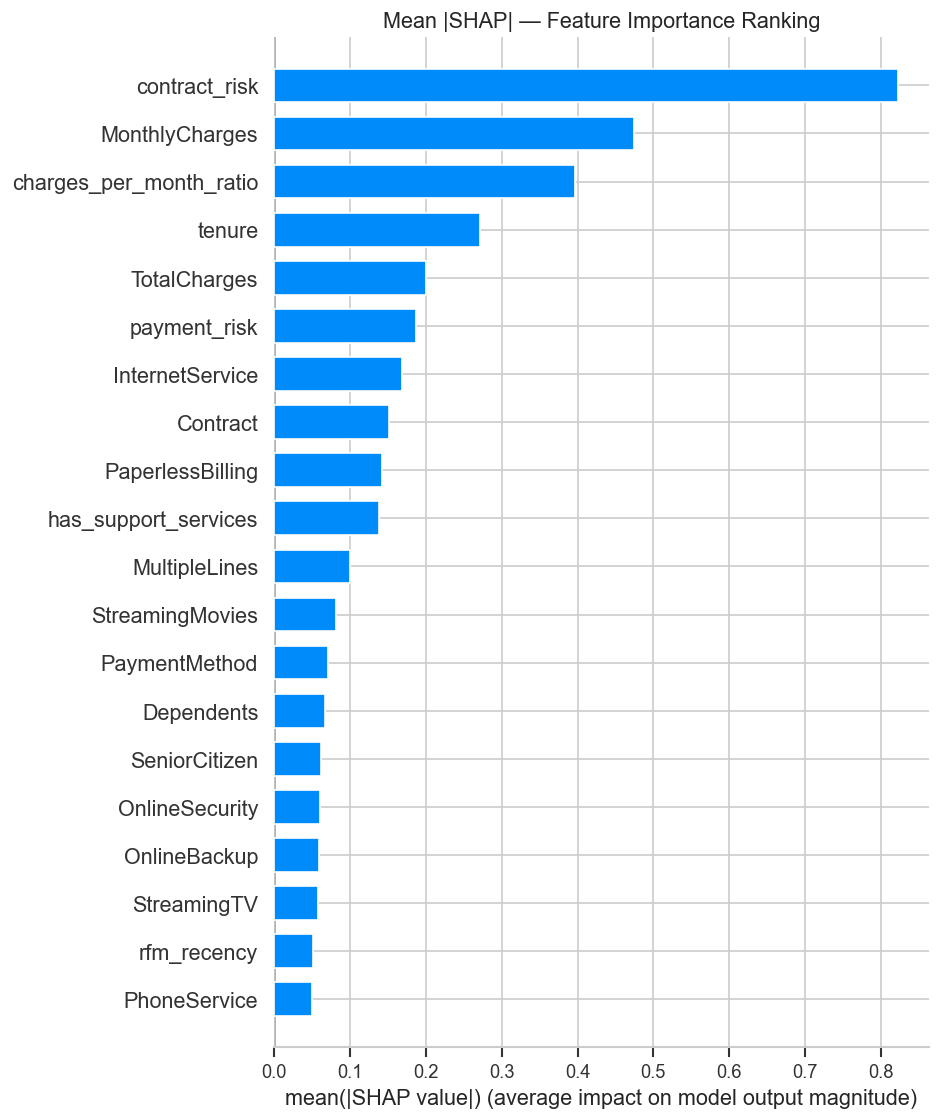

In [15]:
# Bar plot — mean absolute SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, 
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| — Feature Importance Ranking', fontsize=13)
plt.tight_layout()
plt.show()

Explaining customer index 1090 — predicted churn probability: 98.66%


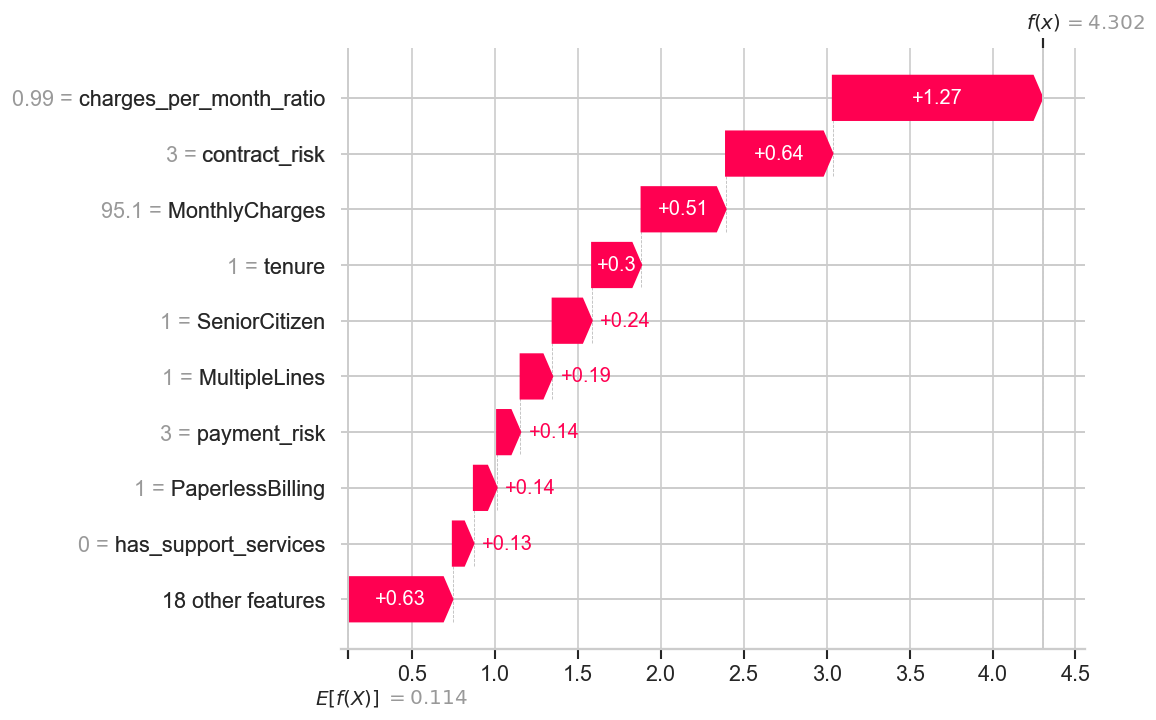

In [16]:
# Explain a single high-risk prediction (waterfall plot)
# Find the customer with the highest predicted churn probability
high_risk_idx = np.argmax(xgb.predict_proba(X_test)[:, 1])
print(f'Explaining customer index {high_risk_idx} — predicted churn probability: '
      f'{xgb.predict_proba(X_test)[high_risk_idx, 1]:.2%}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx].values,
        feature_names=feature_cols
    )
)

## 7. Final Model Selection & Saving

In [17]:
from src.models.train import run_training

print('Running full training pipeline and saving all model artifacts...')
metrics = run_training()
print('\nAll models saved.')

2026-03-12 14:43:56 | INFO | models.train | Dataset: 7043 samples, 27 features
2026-03-12 14:43:56 | INFO | models.train | Churn rate: 26.54%
2026-03-12 14:43:56 | INFO | models.train | Train: 5634 | Test: 1409


Running full training pipeline and saving all model artifacts...


2026-03-12 14:43:57 | INFO | models.train | 
2026-03-12 14:43:57 | INFO | models.train | Model: Logistic Regression
2026-03-12 14:43:57 | INFO | models.train | ROC-AUC : 0.8497
2026-03-12 14:43:57 | INFO | models.train | F1      : 0.621
2026-03-12 14:43:57 | INFO | models.train | Precision: 0.5076
2026-03-12 14:43:57 | INFO | models.train | Recall  : 0.7995
2026-03-12 14:43:57 | INFO | models.train | 
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.80      1035
     Churned       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

2026-03-12 14:44:00 | INFO | models.train | 
2026-03-12 14:44:00 | INFO | models.train | Model: Random Forest
2026-03-12 14:44:00 | INFO | models.train | ROC-AUC : 0.8422
2026-03-12 14:44:00 | INFO | models.train | F1      : 0.6238
2026-03-12 14:44:00 | INFO | models.


MODEL COMPARISON
              model  roc_auc  f1_churn  precision_churn  recall_churn
Logistic Regression   0.8497    0.6210           0.5076        0.7995
      Random Forest   0.8422    0.6238           0.5539        0.7139
            XGBoost   0.8325    0.6268           0.5419        0.7433

All models saved.


Although Logistic Regression had the highest recall, XGBoost achieved the best F1 score, indicating a better balance between precision and recall. Since churn prediction requires both identifying churners and minimizing false positives, XGBoost was selected as the final model.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║           MODELLING KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  BEST MODEL: XGBoost                                     ║
║  • Highest ROC-AUC and F1 on churn class                ║
║  • Handles class imbalance via scale_pos_weight          ║
║  • No scaling required (tree-based)                     ║
║                                                          ║
║  TOP CHURN PREDICTORS (SHAP)                             ║
║  • contract_risk — strongest signal                     ║
║  • tenure / rfm_recency                                 ║
║  • payment_risk (Electronic check)                      ║
║  • engagement_score                                     ║
║  • MonthlyCharges                                       ║
║                                                          ║
║  BUSINESS IMPLICATION                                    ║
║  Month-to-month customers on electronic check with      ║
║  low service adoption and high monthly charges are       ║
║  the highest-priority segment for retention campaigns.  ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

## Author

- **Name:** Takunda Madondo